# Eddy Current b3 Settling Time -- SPS MBB 200 GeV & 26 GeV Cycles

## Physics Motivation

The SPS supercycle follows **LHC_pilot -> MD1 -> SFTPRO**. The LHC pilot
excites the magnet to ~5785 A. During the subsequent MD1 injection plateau
(~301 A), eddy currents cause b3 to drift exponentially:

$$b_3(t) = b_{3,\infty} + A \cdot \exp\!\left(-\frac{t - t_0}{\tau}\right)$$

## Datasets

| Label | Session | Description |
|-------|---------|-------------|
| **200 GeV Extended** | `01_200_extended` | Extended MD1 at 200 GeV, ~20 supercycles |
| **200 GeV Original** | `02_200_original` | Original MD1 at 200 GeV |
| **26 GeV Extended** | `03_26_extended` | Extended MD1 at 26 GeV, ~20 supercycles |
| **26 GeV Original** | `04_26_original` | Original MD1 at 26 GeV |

---
## 1. Configuration

In [1]:
# --- 200 GeV ---
EXT_200_SESSION = "2026_02_06/01_200_extended/20260206_144537_SPS_MBB"
EXT_200_SUBDIR  = "20260206_144559_MBB"
ORIG_200_SESSION = "2026_02_06/02_200_original/20260206_150502_SPS_MBB"
ORIG_200_SUBDIR  = "20260206_150529_MBB"

# --- 26 GeV ---
EXT_26_SESSION = "2026_02_06/03_26_extended/20260206_151808_SPS_MBB"
EXT_26_SUBDIR  = "20260206_151827_MBB"
ORIG_26_SESSION = "2026_02_06/04_26_original/20260206_153712_SPS_MBB"
ORIG_26_SUBDIR  = "20260206_153730_MBB"

# --- Common ---
SEGMENT = "NCS"
KN_CROSS_SESSION = "20251212_171026_SPS_MBA/CRMMMMH_AV-00000001/Kn_values_Seg_Main_A_AC.txt"
MAGNET_ORDER = 1
R_REF = 0.02
SAMPLES_PER_TURN = 1024
OPTIONS = ("dri", "rot", "cel", "fed")
PLATEAU_I_RANGE_MAX = 3.0
MIN_B1_T = 1e-4
MIN_INJECTION_TURNS = 5

print("Eddy Current b3 Settling -- SPS MBB (200 GeV & 26 GeV)")
print("=" * 60)

Eddy Current b3 Settling -- SPS MBB (200 GeV & 26 GeV)


---
## 2. Imports

In [2]:
import sys
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import curve_fit

%matplotlib widget
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

repo_root = Path("../..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    compute_block_averaged_range,
    detect_plateau_turns,
    classify_current,
    find_contiguous_groups,
    process_kn_pipeline,
    build_harmonic_rows,
    diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists():
        break
    REPO_ROOT = REPO_ROOT.parent

KN_PATH = REPO_ROOT / "measurements" / KN_CROSS_SESSION
assert KN_PATH.exists(), f"Kn file not found: {KN_PATH}"
kn = load_segment_kn_txt(str(KN_PATH))
print(f"Kn loaded: {len(kn.orders)} harmonics from {KN_PATH.name}")
print("Imports ready.")

Kn loaded: 15 harmonics from Kn_values_Seg_Main_A_AC.txt
Imports ready.


---
## 3. cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` on high-current turns from the 200 GeV extended dataset.

In [3]:
Ns = SAMPLES_PER_TURN
m = MAGNET_ORDER
FILE_PAT = re.compile(r"Run_(\d+)_I_([\d.]+)A_(N?CS)_raw_measurement_data\.txt$")

_session_dir = REPO_ROOT / "measurements" / EXT_200_SESSION
_run_dir = _session_dir / EXT_200_SUBDIR
_ncs_files = [f for f in sorted(_run_dir.iterdir()) if FILE_PAT.search(f.name) and SEGMENT in f.name]
assert _ncs_files, "No NCS raw file found"
_raw = np.loadtxt(_ncs_files[0])
_n_turns = _raw.shape[0] // Ns
_n_keep = _n_turns * Ns

_t_all = _raw[:_n_keep, 0].reshape(_n_turns, Ns)
_flux_abs = _raw[:_n_keep, 1].reshape(_n_turns, Ns)
_flux_cmp = _raw[:_n_keep, 2].reshape(_n_turns, Ns)
_I_all = _raw[:_n_keep, 3].reshape(_n_turns, Ns)

_I_mean_quick = _I_all.mean(axis=1)
_best_turn = np.argmax(np.abs(_I_mean_quick))
_r1 = robust_range(_raw[_best_turn * Ns:(_best_turn + 1) * Ns, 1])
_r2 = robust_range(_raw[_best_turn * Ns:(_best_turn + 1) * Ns, 2])
if _r2 > _r1:
    _flux_abs = _raw[:_n_keep, 2].reshape(_n_turns, Ns)
    _flux_cmp = _raw[:_n_keep, 1].reshape(_n_turns, Ns)

_I_mean = _I_all.mean(axis=1)
_hi_mask = np.abs(_I_mean) > 4000
if _hi_mask.sum() < 5:
    _hi_mask = np.abs(_I_mean) > np.percentile(np.abs(_I_mean), 90)
_n_diag = min(100, int(_hi_mask.sum()))
_hi_idx = np.where(_hi_mask)[0][:_n_diag]

diag = diagnose_cel_fed(
    _flux_abs[_hi_idx], _flux_cmp[_hi_idx],
    _t_all[_hi_idx], _I_all[_hi_idx],
    kn=kn, r_ref=R_REF, magnet_order=MAGNET_ORDER,
)
print(f"cel/fed diagnostic ({_n_diag} high-I turns from 200 GeV extended):")
print(f"  {diag.recommendation}")
print(f"  {diag.reason}")
_Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
print(f"  B_main max |diff|: {_Bd:.4e} T")
del _session_dir, _run_dir, _ncs_files, _raw, _n_turns, _n_keep
del _t_all, _flux_abs, _flux_cmp, _I_all, _I_mean_quick, _best_turn
del _r1, _r2, _I_mean, _hi_mask, _n_diag, _hi_idx, _Bd

if diag.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"  -> cel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"  -> cel/fed safe, keeping OPTIONS = {OPTIONS}")

cel/fed diagnostic (100 high-I turns from 200 GeV extended):
  UNSAFE
  100/100 turns (100%) have |zR| > 0.0100 (median 0.0514, max 0.0930). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 2.0994e-02 T
  -> cel/fed disabled, OPTIONS = ('dri', 'rot')


---
## 4. Helper: Load & Process One Dataset

In [4]:
N_BLOCKS = 10

def load_and_process(session, meas_subdir, dataset_label=""):
    session_dir = REPO_ROOT / "measurements" / session
    run_dir = session_dir / meas_subdir
    ncs_files = []
    for f in sorted(run_dir.iterdir()):
        match = FILE_PAT.search(f.name)
        if match and match.group(3) == SEGMENT:
            ncs_files.append(f)
    assert ncs_files, f"No {SEGMENT} raw files found in {run_dir}"
    raw_file = ncs_files[0]
    print(f"\n{'='*60}")
    print(f"  Dataset: {dataset_label or session}")
    print(f"  Raw file: {raw_file.name}")

    raw = np.loadtxt(raw_file)
    n_turns = raw.shape[0] // Ns
    n_keep = n_turns * Ns
    print(f"  Shape: {raw.shape} -> {n_turns} turns")
    print(f"  Time span: {raw[-1,0] - raw[0,0]:.1f} s ({(raw[-1,0] - raw[0,0])/60:.1f} min)")

    t_all = raw[:n_keep, 0].reshape(n_turns, Ns)
    flux_abs_all = raw[:n_keep, 1].reshape(n_turns, Ns)
    flux_cmp_all = raw[:n_keep, 2].reshape(n_turns, Ns)
    I_all = raw[:n_keep, 3].reshape(n_turns, Ns)

    I_mean_quick = I_all.mean(axis=1)
    best_turn = np.argmax(np.abs(I_mean_quick))
    r1 = robust_range(raw[best_turn*Ns:(best_turn+1)*Ns, 1])
    r2 = robust_range(raw[best_turn*Ns:(best_turn+1)*Ns, 2])
    if r2 > r1:
        flux_abs_all = raw[:n_keep, 2].reshape(n_turns, Ns)
        flux_cmp_all = raw[:n_keep, 1].reshape(n_turns, Ns)
        print("  (flux columns swapped)")

    I_mean = I_all.mean(axis=1)
    t_mean = t_all.mean(axis=1)
    I_range, I_blocks = compute_block_averaged_range(I_all, Ns, N_BLOCKS)
    plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
    is_plateau = plateau_info["is_plateau"]

    turn_label = np.array(["ramp"] * n_turns, dtype=object)
    for i in range(n_turns):
        if is_plateau[i]:
            turn_label[i] = classify_current(I_mean[i])

    inj_mask = turn_label == "injection"
    inj_groups = find_contiguous_groups(inj_mask, min_length=2)
    print(f"  Plateau turns: {is_plateau.sum()}, Injection groups: {len(inj_groups)}")

    all_rows = []
    for sc_id, (gs, ge) in enumerate(inj_groups):
        idx = np.arange(gs, ge + 1)
        if len(idx) == 0:
            continue
        result, C_merged, C_units, ok_main = process_kn_pipeline(
            flux_abs_turns=flux_abs_all[idx], flux_cmp_turns=flux_cmp_all[idx],
            t_turns=t_all[idx], I_turns=I_all[idx],
            kn=kn, r_ref=R_REF, magnet_order=m,
            options=OPTIONS, min_b1_T=MIN_B1_T,
        )
        t_inj_start = t_mean[gs]
        extra = [
            {"global_turn": int(idx[t]), "label": str(turn_label[idx[t]]),
             "supercycle_id": sc_id,
             "t_since_inj_start": float(t_mean[idx[t]] - t_inj_start)}
            for t in range(len(idx))
        ]
        rows = build_harmonic_rows(result, C_merged, C_units, ok_main, m, extra)
        all_rows.extend(rows)

    df = pd.DataFrame(all_rows)
    print(f"  Injection turns processed: {len(df)}")
    if len(df) > 0:
        print(f"  Supercycles: {df['supercycle_id'].nunique()}")
        print(f"  b3 range: {df['b3_units'].min():.2f} .. {df['b3_units'].max():.2f} units")
    return df, t_mean, I_mean, turn_label, is_plateau, inj_groups

---
## 5. Load All Four Datasets

In [5]:
df_ext200, t_ext200, I_ext200, lbl_ext200, plat_ext200, inj_ext200 = load_and_process(
    EXT_200_SESSION, EXT_200_SUBDIR, "200 GeV Extended")
df_orig200, t_orig200, I_orig200, lbl_orig200, plat_orig200, inj_orig200 = load_and_process(
    ORIG_200_SESSION, ORIG_200_SUBDIR, "200 GeV Original")
df_ext26, t_ext26, I_ext26, lbl_ext26, plat_ext26, inj_ext26 = load_and_process(
    EXT_26_SESSION, EXT_26_SUBDIR, "26 GeV Extended")
df_orig26, t_orig26, I_orig26, lbl_orig26, plat_orig26, inj_orig26 = load_and_process(
    ORIG_26_SESSION, ORIG_26_SUBDIR, "26 GeV Original")


  Dataset: 200 GeV Extended
  Raw file: 20260206_144559_MBB_Run_00_I_100.00A_NCS_raw_measurement_data.txt


  Shape: (1086464, 5) -> 1061 turns
  Time span: 1061.0 s (17.7 min)
  Plateau turns: 604, Injection groups: 20
  Injection turns processed: 480
  Supercycles: 20
  b3 range: 0.01 .. 0.36 units

  Dataset: 200 GeV Original
  Raw file: 20260206_150529_MBB_Run_00_I_100.00A_NCS_raw_measurement_data.txt
  Shape: (92160, 5) -> 90 turns
  Time span: 90.0 s (1.5 min)
  Plateau turns: 40, Injection groups: 0
  Injection turns processed: 0

  Dataset: 26 GeV Extended
  Raw file: 20260206_151827_MBB_Run_00_I_100.00A_NCS_raw_measurement_data.txt


  Shape: (1089536, 5) -> 1064 turns
  Time span: 1064.0 s (17.7 min)
  Plateau turns: 638, Injection groups: 20
  Injection turns processed: 512
  Supercycles: 20
  b3 range: 0.03 .. 0.36 units

  Dataset: 26 GeV Original
  Raw file: 20260206_153730_MBB_Run_00_I_100.00A_NCS_raw_measurement_data.txt
  Shape: (76800, 5) -> 75 turns
  Time span: 75.0 s (1.2 min)
  Plateau turns: 26, Injection groups: 1
  Injection turns processed: 2
  Supercycles: 1
  b3 range: 0.09 .. 0.14 units


---
## 6. Current Profile Overview

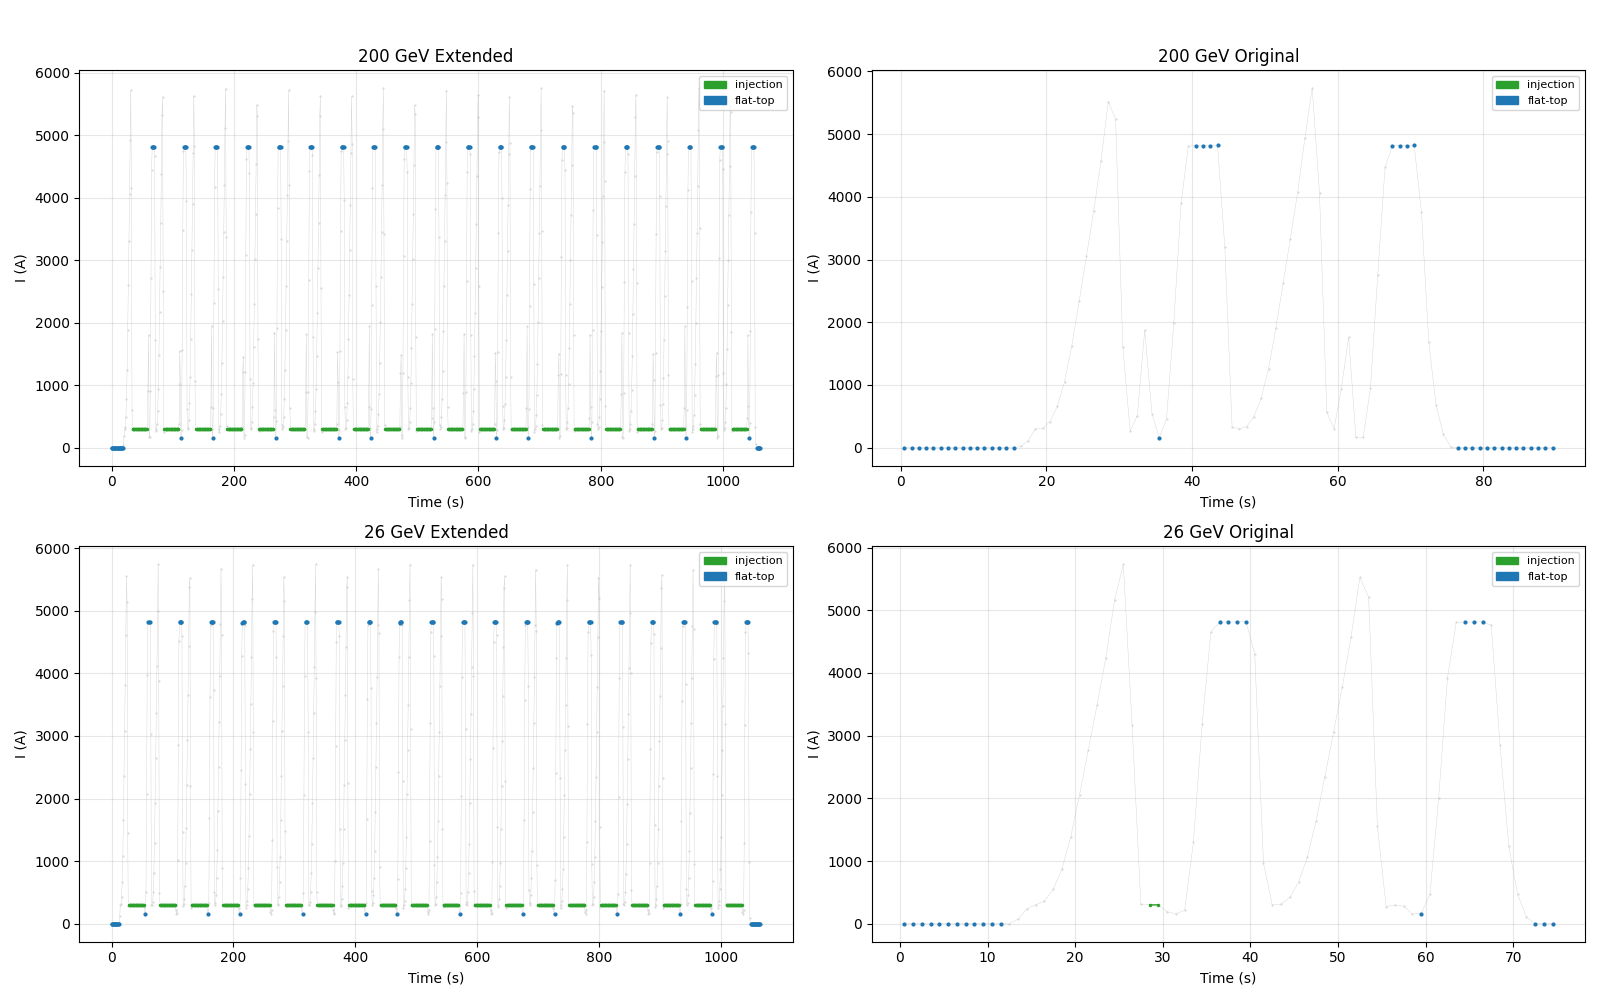

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
datasets_plot = [
    (axes[0,0], t_ext200, I_ext200, lbl_ext200, plat_ext200, inj_ext200, "200 GeV Extended"),
    (axes[0,1], t_orig200, I_orig200, lbl_orig200, plat_orig200, inj_orig200, "200 GeV Original"),
    (axes[1,0], t_ext26, I_ext26, lbl_ext26, plat_ext26, inj_ext26, "26 GeV Extended"),
    (axes[1,1], t_orig26, I_orig26, lbl_orig26, plat_orig26, inj_orig26, "26 GeV Original"),
]
for ax, t_m, I_m, lbl, plat, inj_grps, title in datasets_plot:
    ax.plot(t_m, I_m, ".-", markersize=1, linewidth=0.3, color="lightgrey", zorder=0)
    for gs, ge in inj_grps:
        ax.plot(t_m[gs:ge+1], I_m[gs:ge+1], ".-", markersize=3, linewidth=1, color="tab:green", zorder=2)
    non_inj_plat = (plat) & (lbl != "injection") & (lbl != "ramp")
    idx_nip = np.where(non_inj_plat)[0]
    if len(idx_nip) > 0:
        ax.scatter(t_m[idx_nip], I_m[idx_nip], s=4, color="tab:blue", zorder=2)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("I (A)"); ax.set_title(title)
    ax.legend([Patch(color="tab:green"), Patch(color="tab:blue")],
             ["injection", "flat-top"], fontsize=8, loc="upper right")
fig.suptitle("Current Profiles -- All Datasets", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. b3 vs Time Since Injection Start -- Supercycle Overlay

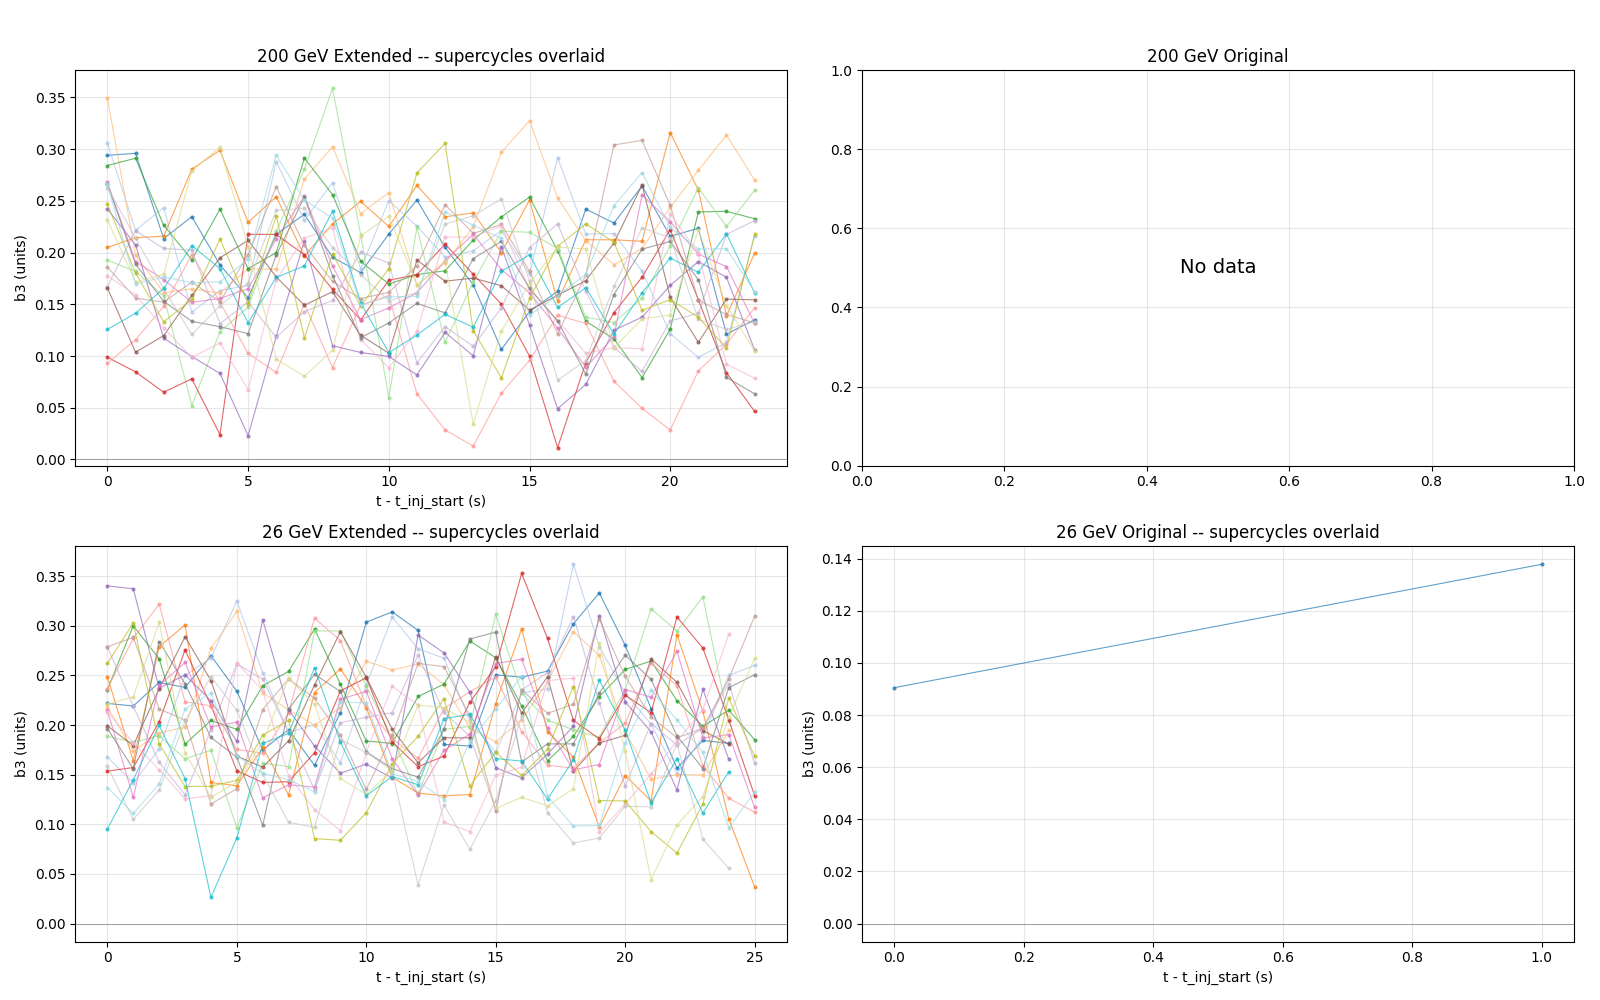

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
all_datasets = [
    (axes[0,0], df_ext200, "200 GeV Extended"), (axes[0,1], df_orig200, "200 GeV Original"),
    (axes[1,0], df_ext26, "26 GeV Extended"), (axes[1,1], df_orig26, "26 GeV Original"),
]
for ax, df, title in all_datasets:
    if len(df) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, fontsize=14)
        ax.set_title(title); continue
    sc_ids = sorted(df["supercycle_id"].unique())
    cmap = plt.cm.tab20(np.linspace(0, 1, max(len(sc_ids), 1)))
    for i, sc_id in enumerate(sc_ids):
        sub = df[df["supercycle_id"] == sc_id]
        ax.plot(sub["t_since_inj_start"], sub["b3_units"], ".-",
                markersize=4, linewidth=0.8, alpha=0.7, color=cmap[i % len(cmap)])
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel("t - t_inj_start (s)"); ax.set_ylabel("b3 (units)")
    ax.set_title(f"{title} -- supercycles overlaid")
fig.suptitle("b3 vs Time Since Injection Start", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Exponential Fit per Supercycle

In [8]:
def eddy_model(t, b3_inf, A, tau):
    return b3_inf + A * np.exp(-t / tau)

def fit_supercycle(df_sc):
    t = df_sc["t_since_inj_start"].values
    b3 = df_sc["b3_units"].values
    ok = np.isfinite(b3) & np.isfinite(t)
    t, b3 = t[ok], b3[ok]
    if len(t) < MIN_INJECTION_TURNS:
        return None
    try:
        popt, pcov = curve_fit(
            eddy_model, t, b3,
            p0=[b3[-1], b3[0] - b3[-1], max(t[-1] / 3, 1.0)],
            bounds=([-np.inf, -np.inf, 0.1], [np.inf, np.inf, 1000]),
            maxfev=5000,
        )
        perr = np.sqrt(np.diag(pcov))
        b3_pred = eddy_model(t, *popt)
        ss_res = np.sum((b3 - b3_pred) ** 2)
        ss_tot = np.sum((b3 - b3.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        return {"b3_inf": popt[0], "A": popt[1], "tau": popt[2],
                "b3_inf_err": perr[0], "A_err": perr[1], "tau_err": perr[2],
                "r2": r2, "n_turns": len(t)}
    except (RuntimeError, ValueError):
        return None

all_dfs = [
    ("200 GeV Ext", df_ext200), ("200 GeV Orig", df_orig200),
    ("26 GeV Ext", df_ext26), ("26 GeV Orig", df_orig26),
]
fit_results = {}
for ds_name, df in all_dfs:
    fits = []
    if len(df) == 0:
        fit_results[ds_name] = fits; continue
    for sc_id in sorted(df["supercycle_id"].unique()):
        result = fit_supercycle(df[df["supercycle_id"] == sc_id])
        if result is not None:
            result["supercycle_id"] = sc_id
            fits.append(result)
    fit_results[ds_name] = fits
    print(f"{ds_name}: {len(fits)} / {df['supercycle_id'].nunique()} supercycles fitted")

df_fits = {name: pd.DataFrame(fits) for name, fits in fit_results.items()}

for name, df_f in df_fits.items():
    if len(df_f) == 0: continue
    print(f"\n{name}:")
    print(f"  {'SC':>3s} {'tau (s)':>10s} {'A (units)':>12s} {'b3_inf':>10s} {'R2':>6s}")
    print(f"  {'-'*45}")
    for _, row in df_f.iterrows():
        print(f"  {int(row['supercycle_id']):3d} {row['tau']:10.2f} {row['A']:+12.4f} "
              f"{row['b3_inf']:+10.4f} {row['r2']:6.3f}")

200 GeV Ext: 20 / 20 supercycles fitted
26 GeV Ext: 20 / 20 supercycles fitted
26 GeV Orig: 0 / 1 supercycles fitted

200 GeV Ext:
   SC    tau (s)    A (units)     b3_inf     R2
  ---------------------------------------------
    0       2.14      +0.1138    +0.1914  0.298
    1    1000.00      +3.2268    -2.9838  0.168
    2    1000.00      +1.1999    -0.9575  0.043
    3    1000.00      -2.3872    +2.5951  0.086
    4       5.87      +0.0958    +0.1816  0.238
    5    1000.00      -2.2140    +2.3773  0.050
    6       2.68      -0.0764    +0.1437  0.093
    7      11.48      +0.0675    +0.0735  0.136
    8       0.99      +0.1317    +0.1198  0.264
    9       2.94      +0.0443    +0.1550  0.066
   10       3.57      -0.0299    +0.1677  0.046
   11       4.94      -0.0401    +0.2016  0.048
   12       0.53      +0.0938    +0.1743  0.179
   13       5.78      -0.0077    +0.1505  0.002
   14       0.69      +0.1136    +0.1538  0.213
   15    1000.00      +2.3598    -2.1527  0.103
   16

---
## 9. Fit Overlay on Representative Supercycles

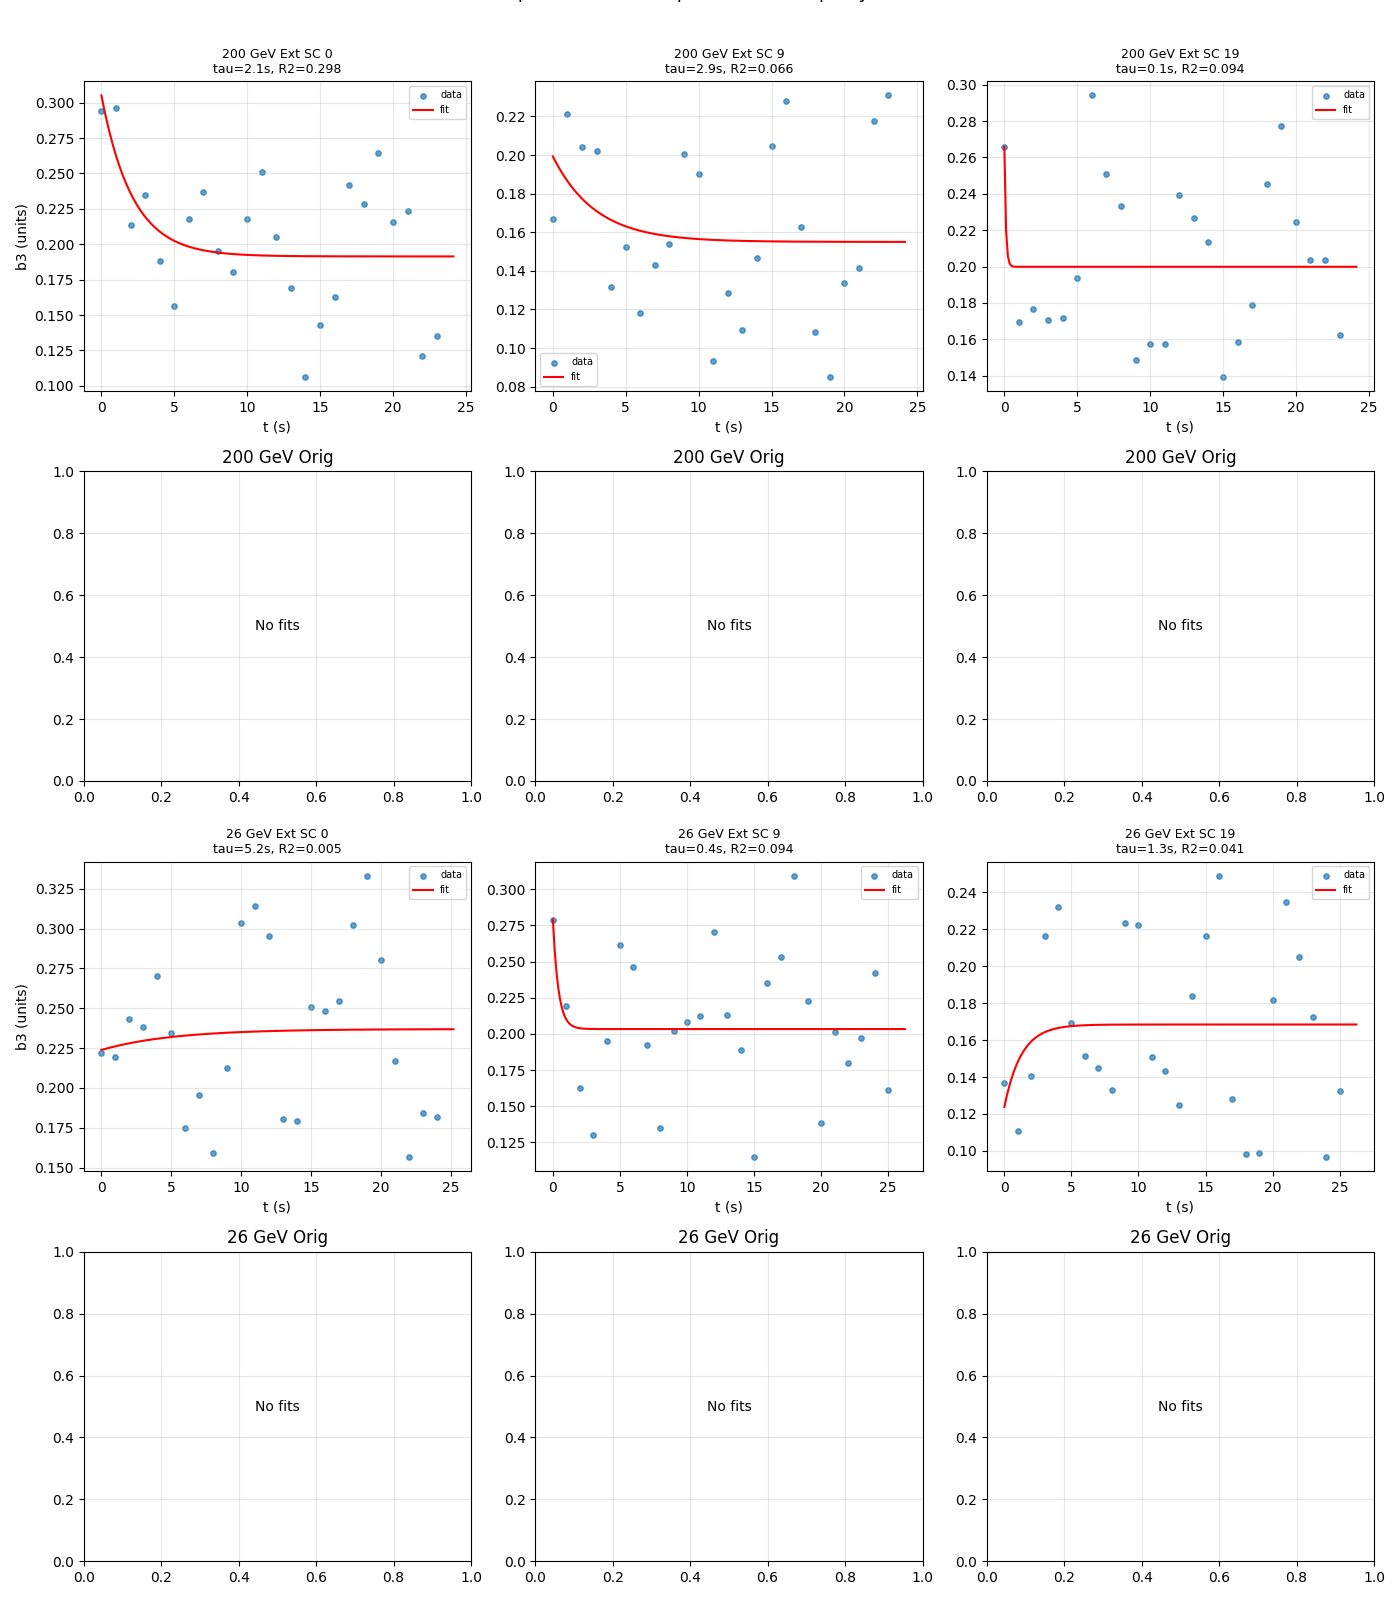

In [9]:
n_show = 3
fig, axes = plt.subplots(4, n_show, figsize=(14, 16))
for row_idx, (ds_name, df, df_f) in enumerate([
    ("200 GeV Ext", df_ext200, df_fits["200 GeV Ext"]),
    ("200 GeV Orig", df_orig200, df_fits["200 GeV Orig"]),
    ("26 GeV Ext", df_ext26, df_fits["26 GeV Ext"]),
    ("26 GeV Orig", df_orig26, df_fits["26 GeV Orig"]),
]):
    if len(df_f) == 0:
        for j in range(n_show):
            axes[row_idx, j].text(0.5, 0.5, "No fits", ha="center", va="center",
                                  transform=axes[row_idx, j].transAxes)
            axes[row_idx, j].set_title(ds_name)
        continue
    sc_ids = df_f["supercycle_id"].values
    show_ids = sc_ids[np.linspace(0, len(sc_ids)-1, min(n_show, len(sc_ids)), dtype=int)]
    for j, sc_id in enumerate(show_ids):
        ax = axes[row_idx, j]
        sub = df[df["supercycle_id"] == sc_id]
        fit_row = df_f[df_f["supercycle_id"] == sc_id].iloc[0]
        ax.scatter(sub["t_since_inj_start"], sub["b3_units"], s=15, alpha=0.7, color="tab:blue", label="data")
        t_fit = np.linspace(0, sub["t_since_inj_start"].max() * 1.05, 200)
        ax.plot(t_fit, eddy_model(t_fit, fit_row["b3_inf"], fit_row["A"], fit_row["tau"]),
                "r-", linewidth=1.5, label="fit")
        ax.set_title(f"{ds_name} SC {int(sc_id)}\ntau={fit_row['tau']:.1f}s, R2={fit_row['r2']:.3f}", fontsize=9)
        ax.set_xlabel("t (s)")
        if j == 0: ax.set_ylabel("b3 (units)")
        ax.legend(fontsize=7)
    for j in range(len(show_ids), n_show):
        axes[row_idx, j].set_visible(False)
fig.suptitle("Exponential Fit -- Representative Supercycles", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Tau Comparison Across All Datasets

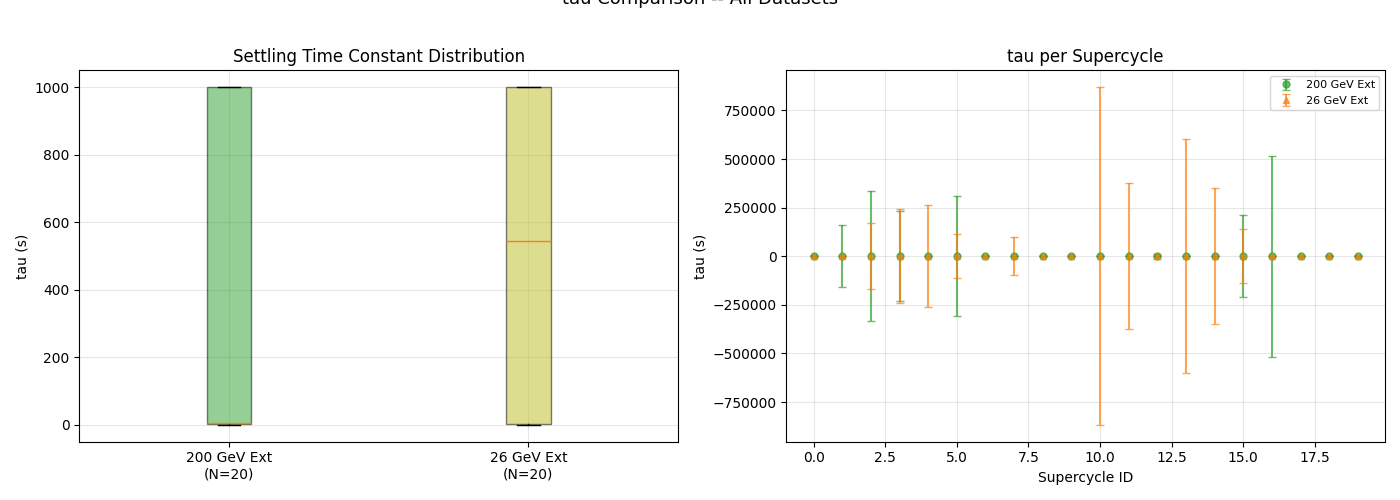


Tau statistics:
           Dataset    N   mean (s)    std (s)     median    R2 mean
  -----------------------------------------------------------------
       200 GeV Ext   20     302.45     456.66       5.36      0.118
      200 GeV Orig   --
        26 GeV Ext   20     506.23     494.09     545.27      0.115
       26 GeV Orig   --


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
box_data, box_labels = [], []
colors_bp = ["tab:green", "tab:olive", "tab:orange", "tab:red"]
for (name, df_f), col in zip(df_fits.items(), colors_bp):
    if len(df_f) > 0:
        box_data.append(df_f["tau"].values)
        box_labels.append(f"{name}\n(N={len(df_f)})")
if box_data:
    bp = ax.boxplot(box_data, tick_labels=box_labels, patch_artist=True)
    for patch, col in zip(bp["boxes"], colors_bp[:len(box_data)]):
        patch.set_facecolor(col); patch.set_alpha(0.5)
ax.set_ylabel("tau (s)"); ax.set_title("Settling Time Constant Distribution")

ax = axes[1]
markers = ["o", "s", "^", "D"]
for (name, df_f), col, marker in zip(df_fits.items(), colors_bp, markers):
    if len(df_f) > 0:
        ax.errorbar(df_f["supercycle_id"], df_f["tau"], yerr=df_f["tau_err"],
                    fmt=marker, color=col, markersize=5, capsize=3, alpha=0.7, label=name)
ax.set_xlabel("Supercycle ID"); ax.set_ylabel("tau (s)")
ax.set_title("tau per Supercycle"); ax.legend(fontsize=8)
fig.suptitle("tau Comparison -- All Datasets", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nTau statistics:")
print(f"  {'Dataset':>16s} {'N':>4s} {'mean (s)':>10s} {'std (s)':>10s} {'median':>10s} {'R2 mean':>10s}")
print(f"  {'-'*65}")
for name, df_f in df_fits.items():
    if len(df_f) == 0:
        print(f"  {name:>16s} {'--':>4s}"); continue
    tau_v = df_f["tau"].values; r2_v = df_f["r2"].values
    print(f"  {name:>16s} {len(df_f):4d} {tau_v.mean():10.2f} {tau_v.std():10.2f} "
          f"{np.median(tau_v):10.2f} {r2_v.mean():10.3f}")

---
## 11. Global Fit (All Supercycles Stacked)

C:\Users\albellel\AppData\Local\Temp\ipykernel_2124\869251368.py:15: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(eddy_model, t_stack, b3_stack,


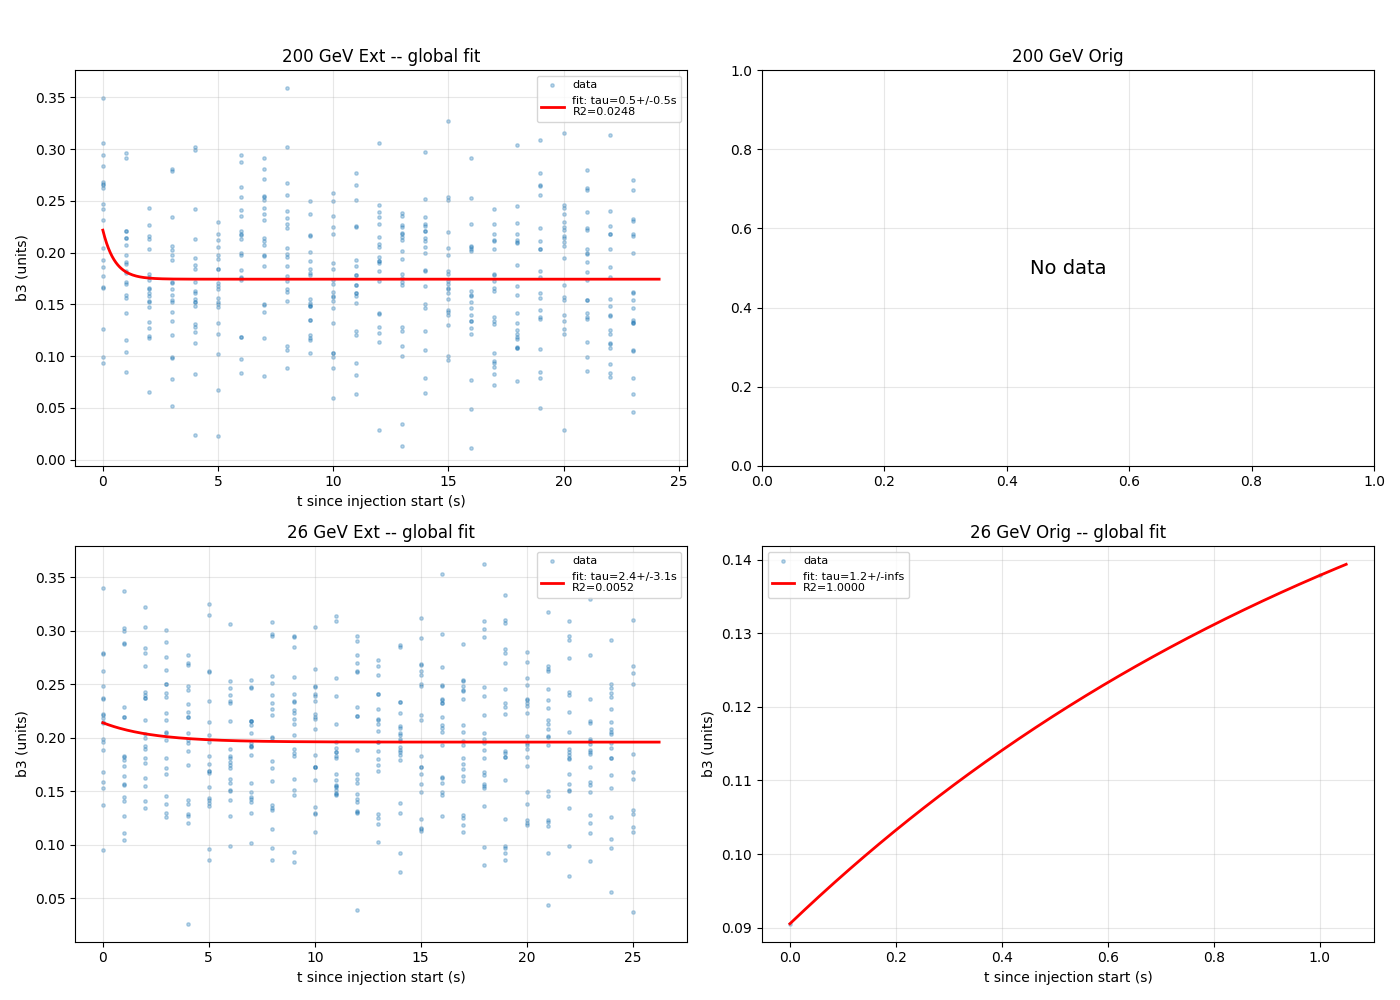


Global fit results:
           Dataset        tau (s)        A (units)         b3_inf       R2      N
  --------------------------------------------------------------------------------
       200 GeV Ext    0.53+/-0.52    +0.0474+/-0.0137  +0.1744+/-0.0029   0.0248    480
      200 GeV Orig -- fit failed --
        26 GeV Ext    2.36+/-3.08    +0.0181+/-0.0121  +0.1960+/-0.0033   0.0052    512
       26 GeV Orig    1.25+/-inf    -0.0858+/-inf  +0.1763+/-inf   1.0000      2


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
global_fits = {}
for ax, (ds_name, df) in zip(axes.ravel(), all_dfs):
    if len(df) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, fontsize=14)
        ax.set_title(ds_name); continue
    t_stack = df["t_since_inj_start"].values
    b3_stack = df["b3_units"].values
    ok = np.isfinite(t_stack) & np.isfinite(b3_stack)
    t_stack, b3_stack = t_stack[ok], b3_stack[ok]
    ax.scatter(t_stack, b3_stack, s=6, alpha=0.3, color="tab:blue", label="data")
    b3_inf_0 = np.median(b3_stack[t_stack > np.percentile(t_stack, 80)])
    A_0 = np.median(b3_stack[t_stack < np.percentile(t_stack, 20)]) - b3_inf_0
    try:
        popt, pcov = curve_fit(eddy_model, t_stack, b3_stack,
            p0=[b3_inf_0, A_0, max(t_stack.max()/3, 1.0)],
            bounds=([-np.inf, -np.inf, 0.1], [np.inf, np.inf, 1000]), maxfev=10000)
        perr = np.sqrt(np.diag(pcov))
        b3_pred = eddy_model(t_stack, *popt)
        ss_res = np.sum((b3_stack - b3_pred) ** 2)
        ss_tot = np.sum((b3_stack - b3_stack.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        global_fits[ds_name] = {"tau": popt[2], "tau_err": perr[2], "A": popt[1], "A_err": perr[1],
                                 "b3_inf": popt[0], "b3_inf_err": perr[0], "r2": r2, "n_points": len(t_stack)}
        t_fit = np.linspace(0, t_stack.max() * 1.05, 300)
        ax.plot(t_fit, eddy_model(t_fit, *popt), "r-", linewidth=2,
                label=f"fit: tau={popt[2]:.1f}+/-{perr[2]:.1f}s\nR2={r2:.4f}")
        ax.legend(fontsize=8)
    except (RuntimeError, ValueError) as e:
        ax.text(0.5, 0.05, f"Fit failed: {e}", ha="center", transform=ax.transAxes, fontsize=9, color="red")
    ax.set_xlabel("t since injection start (s)"); ax.set_ylabel("b3 (units)")
    ax.set_title(f"{ds_name} -- global fit")
fig.suptitle("Global Exponential Fit -- All Supercycles Stacked", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nGlobal fit results:")
print(f"  {'Dataset':>16s} {'tau (s)':>14s} {'A (units)':>16s} {'b3_inf':>14s} {'R2':>8s} {'N':>6s}")
print(f"  {'-'*80}")
for name in [n for n, _ in all_dfs]:
    if name not in global_fits:
        print(f"  {name:>16s} -- fit failed --"); continue
    g = global_fits[name]
    print(f"  {name:>16s} {g['tau']:7.2f}+/-{g['tau_err']:.2f} "
          f"{g['A']:+10.4f}+/-{g['A_err']:.4f} "
          f"{g['b3_inf']:+8.4f}+/-{g['b3_inf_err']:.4f} "
          f"{g['r2']:8.4f} {g['n_points']:6d}")

---
## 12. Summary & Export

In [12]:
print("=" * 70)
print("EDDY CURRENT b3 SETTLING TIME -- SUMMARY")
print("=" * 70)
print(f"\nModel: b3(t) = b3_inf + A * exp(-t/tau)")
print(f"Segment: {SEGMENT}")
print(f"cel/fed: {diag.recommendation}")
print(f"Options: {OPTIONS}")

print(f"\n--- Per-Supercycle Fits ---")
for name, df_f in df_fits.items():
    if len(df_f) == 0:
        print(f"  {name}: no fits"); continue
    tau_v = df_f["tau"].values
    print(f"  {name}: tau = {tau_v.mean():.2f} +/- {tau_v.std():.2f} s "
          f"(N={len(df_f)}, median={np.median(tau_v):.2f} s)")

print(f"\n--- Global Fits ---")
for name in [n for n, _ in all_dfs]:
    if name in global_fits:
        g = global_fits[name]
        print(f"  {name}: tau = {g['tau']:.2f} +/- {g['tau_err']:.2f} s (R2={g['r2']:.4f})")
    else:
        print(f"  {name}: fit failed")

out_dir = REPO_ROOT / "output" / "2026_02_06" / "eddy_current_b3_settling"
out_dir.mkdir(parents=True, exist_ok=True)
for short, df in [("ext200", df_ext200), ("orig200", df_orig200),
                   ("ext26", df_ext26), ("orig26", df_orig26)]:
    if len(df) > 0:
        fname = f"b3_injection_{short}.csv"
        df.to_csv(out_dir / fname, index=False)
        print(f"Wrote {out_dir / fname}  ({len(df)} rows)")
for short, df_f in [("ext200", df_fits["200 GeV Ext"]), ("orig200", df_fits["200 GeV Orig"]),
                      ("ext26", df_fits["26 GeV Ext"]), ("orig26", df_fits["26 GeV Orig"])]:
    if len(df_f) > 0:
        fname = f"b3_fits_{short}.csv"
        df_f.to_csv(out_dir / fname, index=False)
        print(f"Wrote {out_dir / fname}  ({len(df_f)} rows)")
if global_fits:
    df_global = pd.DataFrame([{"dataset": k, **v} for k, v in global_fits.items()])
    df_global.to_csv(out_dir / "b3_global_fit_summary.csv", index=False)
    print(f"Wrote b3_global_fit_summary.csv  ({len(df_global)} rows)")
print("\nDone.")

EDDY CURRENT b3 SETTLING TIME -- SUMMARY

Model: b3(t) = b3_inf + A * exp(-t/tau)
Segment: NCS
cel/fed: UNSAFE
Options: ('dri', 'rot')

--- Per-Supercycle Fits ---
  200 GeV Ext: tau = 302.45 +/- 456.66 s (N=20, median=5.36 s)
  200 GeV Orig: no fits
  26 GeV Ext: tau = 506.23 +/- 494.09 s (N=20, median=545.27 s)
  26 GeV Orig: no fits

--- Global Fits ---
  200 GeV Ext: tau = 0.53 +/- 0.52 s (R2=0.0248)
  200 GeV Orig: fit failed
  26 GeV Ext: tau = 2.36 +/- 3.08 s (R2=0.0052)
  26 GeV Orig: tau = 1.25 +/- inf s (R2=1.0000)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\eddy_current_b3_settling\b3_injection_ext200.csv  (480 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\eddy_current_b3_settling\b3_injection_ext26.csv  (512 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\eddy_current_b3_settling\b3_injection_orig26.csv  (2 rows)
Wrote C:\Users\albellel\python-projects\rotati